В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням Decision Trees і зробимо новий submission на змагання на Kaggle.

В цьому ДЗ ми працюємо без pipelines, бо так буде зручніше для візуалізації і інтерпретації моделі дерева прийняття рішень. Так буває і в робочих проєктах: іноді зручніше використати sklearn.Pipelines, іноді зручніше без них. На етапі пошуку рішення (research) зручніше без пайплайнів, а з пайплайнами - коли ви відлагодили процес обробки даних і хочете поекспериментувати з різними моделями і гіперпараметрами.

**Завдання 1.**

У попередньому домашньому завданні, `HW 2.7 Логістична регресія з scikit learn.ipynb`, ми писали обробку даних для змагання. Ваше завдання зараз - за прикладом, наведеним в лекції `Майстер-клас з перенесення коду з jupyter notebook у Python модуль`, перенести попередню обробку сирих даних з вашого розв'язку ДЗ 2.7 у файл `process_bank_churn.py` в функцію `preprocess_data(...)`.

Функція `preprocess_data()` має приймати `raw_df` і вертати `X_train`, `train_targets`, `X_val`, `val_targets`, `input_cols`(перелік назв колонок, які Ви використовуєте в X), `scaler`, `encoder`, які ми потім будемо використовувати для тренування дерева прийняття рішень.


### Кроки попередньої обробки:

1. Обираємо колонки для роботи. В цьому завдання для чистоти експериментів рекомендую прибрати колонку `Surname`, так буде простіше інтрепретувати модель. Ви можете її додати вже за самостійних подальших експериментів.
2. Розбиття сирих даних на тренувальні і валідаційні.
3. Обробка категоріальних даних (one hot encoding).
4. Масштабування числових даних (було частиною попередньої обробки в попередніх завданнях). Для дерев нам не обовʼязково масштабувати ознаки, тож в коді можна зробити цю частину опціональною, додавши в `preprocess_data` параметр `scaler_numeric`, який приймає значення `True` або `False`. Це дозволить використовувати код попередньоъ обробки з різними моделями.


### Інструкції:
1. Перенесіть попередню обробку даних у файл `process_bank_churn.py`.
2. Забезпечте модулярну структуру функцій: кожна функція повинна виконувати лише одну дію, наприклад, масштабувати ознаки.
3. Додайте докстрінги до кожної функції.
4. Використовуйте typing для аргументів та значень, що повертаються функціями.
5. Передбачте обробку нових даних. Додайте спеціальну функцію `preprocess_new_data(...)`, яка приймає на вхід нові дані в вигляді pandas DataFrame та використовує вже навчені скейлер та енкодер (передані теж як аргументи фукнціх) для їх обробки. Ця функція буде корисною для обробки нових даних перед передбаченням або оцінкою моделі, коли оброблятимемо `test.csv`.

Можна і рекомендовано виконувати це завдання з ChatGPT (бажано, новіше, ніж 3.5) як було наведено у відео-прикладі, тільки **ваше додаткове завдання - розібратись з кодом, який вам згенерувала мовна модель :)**.

## В результаті цього завдання

1. Завантажте ваш готовий `process_bank_churn.py` файл на GitHub у свій репозиторій.
2. Додайте посилання на файл в репозиторії тут у ноутбуці.
3. Нижче зробіть імпорт функції `preprocess_data` з вашого модуля `process_bank_churn.py`.



https://github.com/GAlexGuru/homework-ML/blob/main/process_bank_churn.py

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks')

In [28]:
import importlib
import process_bank_churn

importlib.reload(process_bank_churn)

from process_bank_churn import preprocess_data, preprocess_new_data

**Завдання 2.**
1. Натренуйте дерево прийняття рішень з зафіксованим `random_state` і з рештою аргументів за замовченням.
2. Виведіть area under ROC для моделі на тренувальних і тестувальних даних. Нам потрібна ця метрика, бо вона основна в змаганні. Модель ок, чи є пере- або недотренування?
3. Виведіть глибину дерева.
4. Побудуйте дерево до глибини 2 включно. Напишіть, які ознаки бачите, що є найвпливовішими тут?
5. Створіть датафрейм `importance_df` з feature importances, де в першому стовпчику `feature` - назва ознаки з нашого Х, а в другому `importance` - значення, наскільки ця ознака є важливою в побудованій моделі. Виведіть топ 10 найвпливовіших ознак разом з їх скором важливості (можна або у вигляді таблиці, або в вигляді barplot).

In [13]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
raw_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/train.csv')

data = preprocess_data(raw_df, scaler_numeric=True)

X_train, y_train = data['X_train'], data['train_targets']
X_val, y_val = data['X_val'], data['val_targets']

In [12]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

def get_auc(model, X, y):
  probs = model.predict_proba(X)[:, 1]
  return roc_auc_score(y, probs)

train_auc = get_auc(model, X_train, y_train)
val_auc = get_auc(model, X_val, y_val)

print(f"AUROC на тренувальних даних: {train_auc:.4f}")
print(f"AUROC на валідаційних даних: {val_auc:.4f}")

# 3. Визначаємо глибину дерева
print(f"Глибина дерева: {model.get_depth()}")

AUROC на тренувальних даних: 1.0000
AUROC на валідаційних даних: 0.7702
Глибина дерева: 26


Є перенавчання

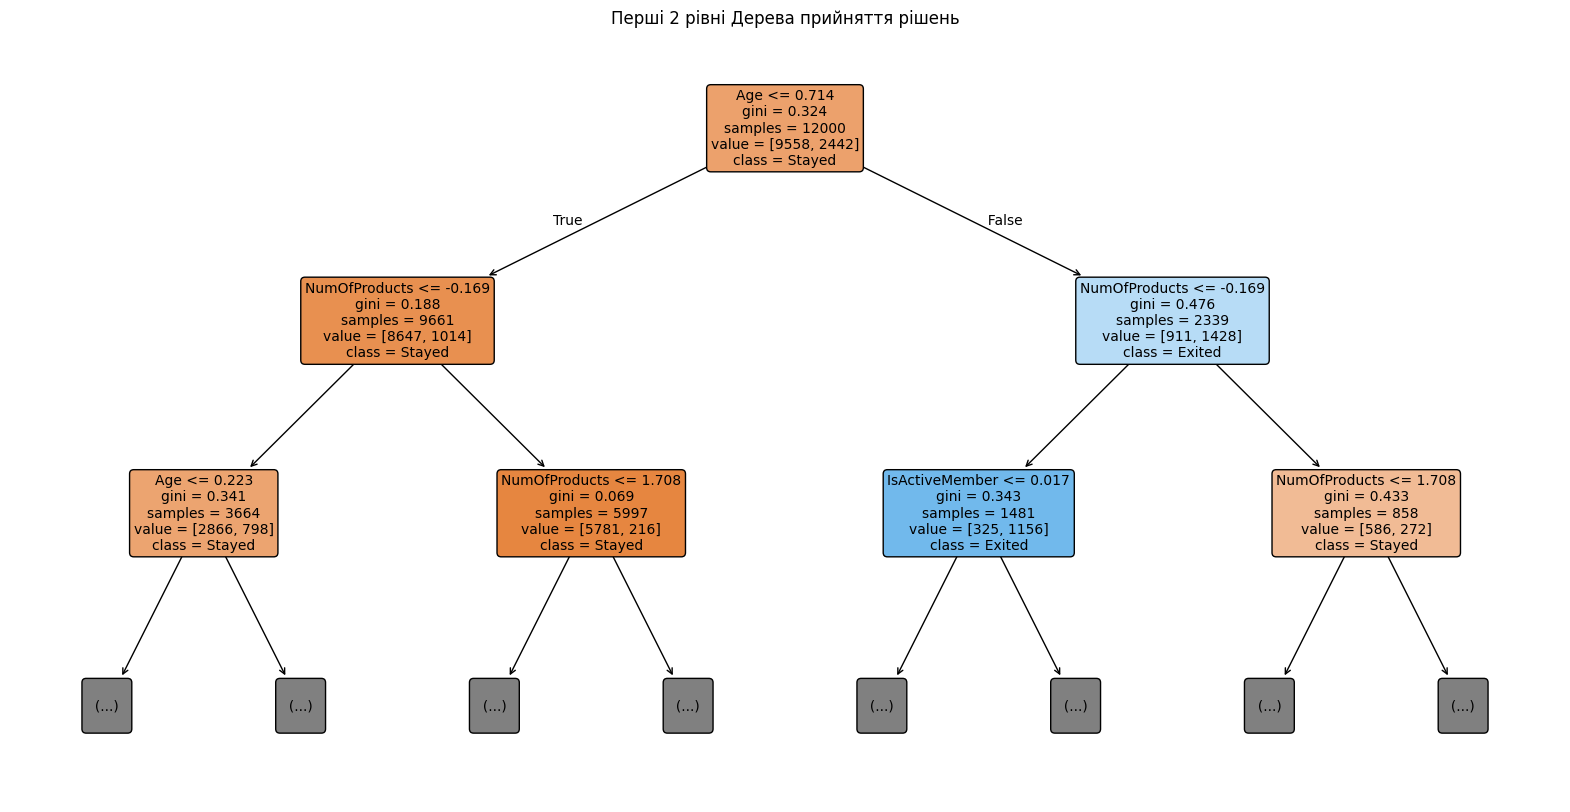


Топ-10 найвпливовіших ознак:
              feature  importance
1                 Age    0.356789
4       NumOfProducts    0.168379
7     EstimatedSalary    0.123635
0         CreditScore    0.123283
3             Balance    0.079192
2              Tenure    0.052899
6      IsActiveMember    0.032688
11      Gender_Female    0.014908
9   Geography_Germany    0.014725
5           HasCrCard    0.012957


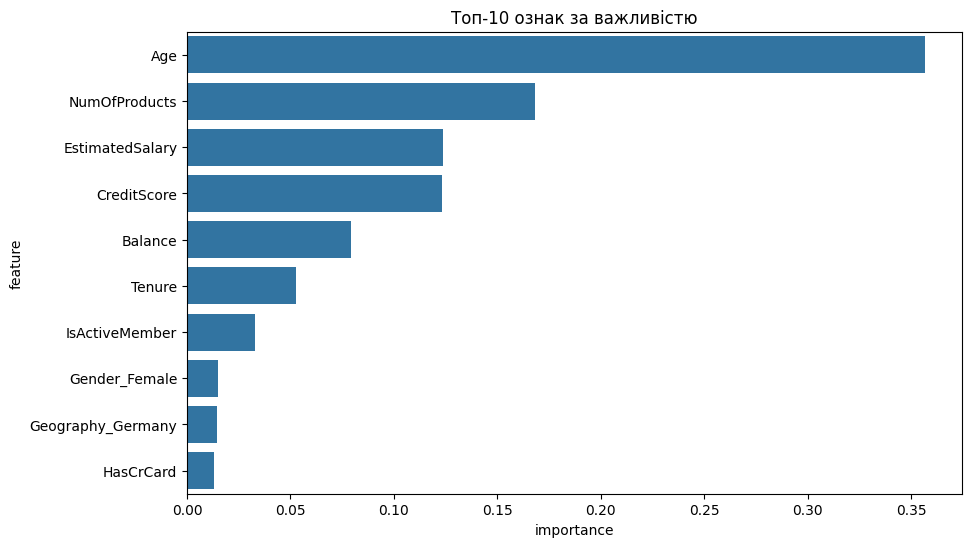

In [15]:
plt.figure(figsize=(20, 10))
plot_tree(model,
          feature_names=X_train.columns.tolist(),
          max_depth=2,
          filled=True,
          class_names=['Stayed', 'Exited'],
          rounded=True)
plt.title("Перші 2 рівні Дерева прийняття рішень")
plt.show()

importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nТоп-10 найвпливовіших ознак:")
print(importance_df.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x='importance', y='feature')
plt.title('Топ-10 ознак за важливістю')
plt.show()

Найвпливовіші ознаки Age та NumOfProducts

**Завдання 3**. Спробуйте знайти такі параметри моделі `DecisionTree` аби модель генералізувала ліпше (був вищий показник AUROC на валідаційній вибірці). Проекспериментуйте з різними значеннями параметрів `max_leaf_nodes`, `max_depth` та лишіть ті, які дають найкращий результат, разом з відповідними AUROC на тренувальній і валідаційній вибірках.

В цьому завданні спробуйте просто знайти параметри методом "тика" :)

In [26]:
def evaluate_params(max_depth=None, max_leaf_nodes=None):
  model = DecisionTreeClassifier(
      max_depth=max_depth,
      max_leaf_nodes=max_leaf_nodes,
      random_state=42
  )
  model.fit(X_train, y_train)

  train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
  val_auc = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

  print(f"Параметри: max_depth={max_depth}, max_leaf_nodes={max_leaf_nodes}")
  print(f"AUROC Train: {train_auc:.4f}")
  print(f"AUROC Val: {val_auc:.4f}")
  print(f"Різниця:{train_auc - val_auc:.4f}\n")


evaluate_params(max_depth=5)
evaluate_params(max_depth=10)
evaluate_params(max_leaf_nodes=20)
evaluate_params(max_leaf_nodes=50)
evaluate_params(max_depth=6, max_leaf_nodes=35)
evaluate_params(max_depth=7, max_leaf_nodes=35)
evaluate_params(max_depth=7, max_leaf_nodes=37)
evaluate_params(max_depth=6, max_leaf_nodes=37)
evaluate_params(max_depth=5, max_leaf_nodes=37)

Параметри: max_depth=5, max_leaf_nodes=None
AUROC Train: 0.9257
AUROC Val: 0.9219
Різниця:0.0038

Параметри: max_depth=10, max_leaf_nodes=None
AUROC Train: 0.9698
AUROC Val: 0.8484
Різниця:0.1213

Параметри: max_depth=None, max_leaf_nodes=20
AUROC Train: 0.9179
AUROC Val: 0.9173
Різниця:0.0006

Параметри: max_depth=None, max_leaf_nodes=50
AUROC Train: 0.9312
AUROC Val: 0.9235
Різниця:0.0077

Параметри: max_depth=6, max_leaf_nodes=35
AUROC Train: 0.9282
AUROC Val: 0.9226
Різниця:0.0056

Параметри: max_depth=7, max_leaf_nodes=35
AUROC Train: 0.9281
AUROC Val: 0.9236
Різниця:0.0045

Параметри: max_depth=7, max_leaf_nodes=37
AUROC Train: 0.9285
AUROC Val: 0.9241
Різниця:0.0044

Параметри: max_depth=6, max_leaf_nodes=37
AUROC Train: 0.9284
AUROC Val: 0.9220
Різниця:0.0064

Параметри: max_depth=5, max_leaf_nodes=37
AUROC Train: 0.9257
AUROC Val: 0.9219
Різниця:0.0038



**Завдання 4**. В циклі пройдіться по значенням max_depth від 1 до 20 включно, на кожній ітерації натренуйте DecisionTree модель і виміряйте AUROC на трейн і валідаційних даних.

В кінці виведіть на графік залеєність між AUROC на трейн і валідаційних даних і номером ітерації.

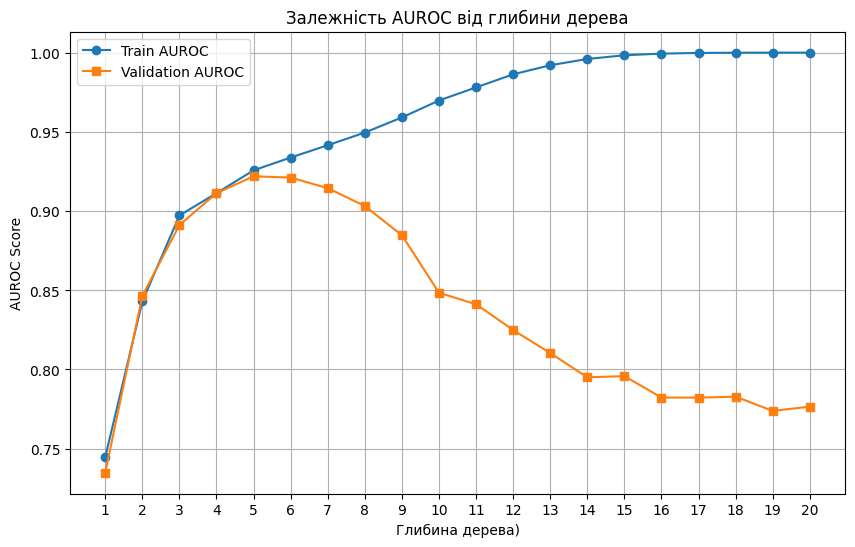

Найкращий AUROC на валідації: 0.9219 при max_depth=5


In [27]:
depths = list(range(1, 21))
train_auroc_scores = []
val_auroc_scores = []
for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    train_probs = model.predict_proba(X_train)[:, 1]
    train_auroc_scores.append(roc_auc_score(y_train, train_probs))

    val_probs = model.predict_proba(X_val)[:, 1]
    val_auroc_scores.append(roc_auc_score(y_val, val_probs))

plt.figure(figsize=(10, 6))
plt.plot(depths, train_auroc_scores, label='Train AUROC', marker='o')
plt.plot(depths, val_auroc_scores, label='Validation AUROC', marker='s')

plt.xlabel('Глибина дерева)')
plt.ylabel('AUROC Score')
plt.title('Залежність AUROC від глибини дерева')
plt.xticks(depths)
plt.legend()
plt.grid(True)
plt.show()

best_depth = depths[val_auroc_scores.index(max(val_auroc_scores))]
print(f"Найкращий AUROC на валідації: {max(val_auroc_scores):.4f} при max_depth={best_depth}")

**Завдання 5**.
1. Натренуйте модель `DecisionTree` з найкращим значенням `max_depth`, яке ви знайшли на попередній ітерації.
2. Завантажте тестові дані змагання з `test.csv`.
3. Зробіть попередню обробку даних з функцією `preprocess_new_data` з вашого модуля `process_bank_churn.py`.
4. Зробіть передбачення використовуючи цю модель на тестових даних змагання.
5. Сформуйте `submission.csv`.
6. Зробіть новий Submission на Kaggle і додайте тут скріншот Вашого скору на паблік лідерборді :)


In [29]:
test_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/test.csv')

final_model = DecisionTreeClassifier(max_depth=7, max_leaf_nodes=37, random_state=42)
final_model.fit(X_train, y_train)

X_test_processed = preprocess_new_data(
    test_df,
    input_cols=data['input_cols'],
    scaler=data['scaler'],
    encoder=data['encoder']
)

probs = final_model.predict_proba(X_test_processed)[:, 1]

submission_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/sample_submission.csv')

submission_df['Exited'] = probs
submission_df.to_csv('/content/drive/MyDrive/Colab Notebooks/submission_tree_1.csv', index=False)

In [30]:
print(submission_df.head())

      id    Exited
0  15000  0.171206
1  15001  0.014371
2  15002  0.014371
3  15003  0.770925
4  15004  0.014371
